# Minimum Spanning Tree

In [54]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
%matplotlib inline

## Gráficos ponderados (weighted graphs)

In [55]:
graph_data = {'A': {'B':2, 'C':3},
         'B': {'A':2, 'C':2, 'D':2},
         'C': {'A':3, 'B':2, 'D':3, 'E':2},
         'D': {'B':2, 'C':3, 'E':1, 'F':3},
         'E': {'C':2, 'D':1, 'F':1},
         'F': {'D':3, 'E':1}}

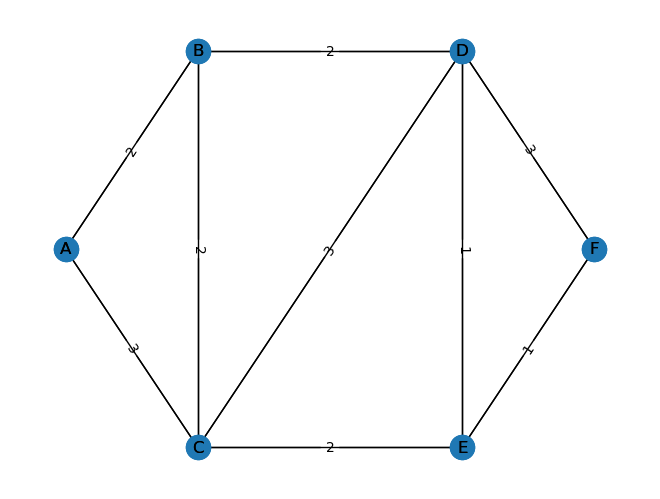

In [56]:
graph = nx.Graph()
for node in graph_data:
    graph.add_nodes_from(node)
    for edge, weight in graph_data[node].items():
        graph.add_edge(node,edge, weight=weight)

pos = { 'A': [0.00, 0.50], 'B': [0.25, 0.75],
        'C': [0.25, 0.25], 'D': [0.75, 0.75],
        'E': [0.75, 0.25], 'F': [1.00, 0.50]}

labels = nx.get_edge_attributes(graph,'weight')
nx.draw(graph, pos, with_labels=True)
nx.draw_networkx_edge_labels(graph, pos, 
                             edge_labels=labels)
# nx.draw_networkx(graph,pos)
plt.show()

## Fila de prioridade (priority queue)

In [57]:
from heapq import heapify, heappop, heappush
from typing import Dict, List, Tuple

class PriorityQueue():
    def __init__(self):
        self.queue: List[Tuple[int, str]] = list()
        heapify(self.queue)
        self.index: Dict[str, int] = dict()

    def push(self, priority: int, label : str):
        if label in self.index:
            self.queue = [(weight, queue_label) for weight,queue_label 
                            in self.queue if queue_label != label]
            heapify(self.queue)
        heappush(self.queue, (priority, label))
        self.index[label] = priority
    
    def pop(self):
        if self.queue:
            return heappop(self.queue)

    def __contains__(self, label):
        return label in self.index
    def __len__(self):
        return len(self.queue)

### Prim

Passos:

1. Monitora ambas as arestas da árvore de extensão mínima e os vértices usados conforme eles se tornam parte da solução.

2. Começa de qualquer vértice no grafo e coloca-o na solução.

3. Determina se ainda há vértices que não são parte da solução:

    a. Enumera as arestas que tocam os vértices na solução.

    b. Insere a aresta com o menor peso na árvore de extensão (este é o princípio guloso em funcionamento no algoritmo: sempre escolhe o mínimo a cada passo para obter o resultado geral mínimo

In [58]:
from typing import Dict, Optional, Any

def prim(graph: Dict[str, Optional[Any]], start: str):
    tree_path: Dict[str, Optional[Any]] = {}
    total = 0
    queue = PriorityQueue()
    queue.push(0 , (start, start))
    while queue:
        weight, (node_start, node_end) = queue.pop()
        if node_end not in tree_path:
            tree_path[node_end] = node_start
            if weight:
                print(f"Added edge from {node_start} to {node_end} weighting {weight}")
                total += weight
            for next_node, weight \
            in graph[node_end].items():
                queue.push(weight , (node_end, next_node))
    print (f"Total spanning tree length: {total}")
    return tree_path

tree_path = prim(graph_data, 'A')

Added edge from A to B weighting 2
Added edge from B to C weighting 2
Added edge from B to D weighting 2
Added edge from D to E weighting 1
Added edge from E to F weighting 1
Total spanning tree length: 8


In [59]:
from typing import Dict, Optional
def represent_tree(tree_path: Dict[str, Optional[Any]]):
    progression = list()
    for node in tree_path:
        if node != tree_path[node]:
            progression.append((tree_path[node], node))
    return sorted(progression, key=lambda x:x[0])

In [60]:
print(represent_tree(tree_path))

[('A', 'B'), ('B', 'C'), ('B', 'D'), ('D', 'E'), ('E', 'F')]


### Kruskal

Passos:

1. Põe todas as arestas em um heap e então ordena-as para que as mais curtas fiquem no topo.

2. Cria um conjunto de árvores, cada uma contendo apenas um vértice (para que o número de árvores seja o mesmo número de vértices). Conecta árvores como um agregado até que as árvores convirjam em uma única árvore de tamanho mínimo que abranja todos os vértices.

3. Repete as operações a seguir até que a solução não contenha tantas arestas quanto o número de vértices no grafo:

    a. Escolhe a aresta mais curta do heap.
    
    b. Determina se os dois vértices conectados pela aresta aparecem em árvores diferentes dentre o conjunto de árvores conectadas.
    
    c. Quando as árvores diferem, ele as conecta usando a aresta (definindo uma agregação).
    
    d. Quando os vértices aparecem na mesma árvore, descarta a aresta.
    
    e. Repete os passos de a até d para as arestas restantes no heap. 

In [77]:
from typing import Dict, Optional, Any

def kruskal(graph: Dict[str, Optional[Any]]):
    priority = PriorityQueue()
    print("Pushing all edges into the priority queue")
    tree_path = list()
    connected = dict()
    for node in graph:
        connected[node] = [node]
        for dest, weight in graph[node].items():
            priority.push(weight, (node,dest))
    print(f"Totally {len(priority)} edges")
    print(f"Connected components: {connected.values()}")
    
    total = 0
    while len(tree_path) < (len(graph)-1):
        (weight, (start, end)) = priority.pop()
        if end not in connected[start]:
            tree_path.append((start, end))
            print(f"Summing {connected[start]} and {connected[end]} components:")
            print(f"\tadded edge from {start} to {end} weighting {weight}")
            total += weight
            connected[start] += connected[end][:]
            for element in connected[end]:
                connected[element]= connected[start]
    print(f"Total spanning tree length: {total}")
    return sorted(tree_path, key=lambda x:x[0])

print(f"\nMinimum spanning tree: {kruskal(graph_data)}")

Pushing all edges into the priority queue
Totally 18 edges
Connected components: dict_values([['A'], ['B'], ['C'], ['D'], ['E'], ['F']])
Summing ['D'] and ['E'] components:
	added edge from D to E weighting 1
Summing ['D', 'E'] and ['F'] components:
	added edge from E to F weighting 1
Summing ['A'] and ['B'] components:
	added edge from A to B weighting 2
Summing ['A', 'B'] and ['C'] components:
	added edge from B to C weighting 2
Summing ['A', 'B', 'C'] and ['D', 'E', 'F'] components:
	added edge from B to D weighting 2
Total spanning tree length: 8

Minimum spanning tree: [('A', 'B'), ('B', 'C'), ('B', 'D'), ('D', 'E'), ('E', 'F')]


Quanto ao tempo de execução, ambos os algoritmos fornecem resultados similares, com taxa de complexidade Big-O de $\text{O}(\text{E}\log(\text{V}))$, na qual E é o número de arestas e V, o número de vértices. Porém, você deve levar em conta como eles solucionam o problema, pois há diferenças na média do tempo esperado de execução.

 Usando um heap Fibonacci, a complexidade de execução do algoritmo de Prim pode mudar para $\text{O}(\text{E} + \text{V} \cdot \log(\text{V}))$, o que é claramente vantajoso se você tem muitas arestas (o componente E agora é somado, em vez de multiplicado), em comparação ao tempo de execução $\text{O}(\text{E}\log(\text{V}))$ anteriormente reportado.